In [1]:
import rawpy
import os
import glob
import numpy as np
from sklearn.linear_model import TheilSenRegressor
import pandas as pd
import matplotlib.pyplot as plt
import random
import scipy
import torch
import torch.nn.functional as F
import sys
import pickle

# Read a real noisy image

In [2]:
def pack_raw(raw, rescale=True):
    # pack Bayer image to 4 channels
    im = raw.raw_image_visible.astype(np.float32)
    im = np.maximum(im - 512, 0) # subtract the black level
    if rescale:
        im = im / (16383 - 512) 

    im = np.expand_dims(im, axis=2)
    img_shape = im.shape
    H = img_shape[0]
    W = img_shape[1]

    out = np.concatenate((im[0:H:2, 0:W:2, :], # r
                          im[0:H:2, 1:W:2, :], # g
                          im[1:H:2, 1:W:2, :], # b
                          im[1:H:2, 0:W:2, :]), axis=2) # g
    return out


def pack_np_raw(im):
    im = np.expand_dims(im, axis=2)
    img_shape = im.shape
    H = img_shape[0]
    W = img_shape[1]

    out = np.concatenate((im[0:H:2, 0:W:2, :], # r
                          im[0:H:2, 1:W:2, :], # g
                          im[1:H:2, 1:W:2, :], # b
                          im[1:H:2, 0:W:2, :]), axis=2) # g
    return out 
    

def get_files_per_iso(df,iso):
    """
    df is the panda dataframe which contains the metadata of the dataset
    iso is an int
    returns a list of pairs of gt and noisy image at some specific ISO
    """
    iso_string = "ISO"+str(iso)
    tmp = df[df["ISO"] == iso_string]
    pathes = tmp["path"].values
    pathes_long = tmp["path_long"].values
    pairs = []
    for i in range(len(pathes)):
        pairs.append((pathes[i],pathes_long[i]))
        
    return(pairs)


def read_raw_to_numpy(path):
    img = rawpy.imread(path)
    img = pack_raw(img, rescale=True)
    img = img.transpose(2,0,1)
    return img


def visualize(darkframe,vmin=None,vmax=None):
    noise_vis = darkframe.copy()
    plt.figure(figsize = (10,5))

    noise_vis = noise_vis[...]
    if vmin is None and vmax is None:
        im = plt.imshow(noise_vis)
    else:
        im = plt.imshow(noise_vis, vmin = vmin,vmax = vmax)
    plt.colorbar(im, orientation='vertical')  # Adds color bar to the right
    plt.axis('off')
    # plt.savefig(os.path.join(save_folder, save_name + '.png'), bbox_inches='tight', pad_inches=0)
    plt.show()

In [3]:
path_csv = "/scratch/students/2023-fall-sp-liying/dataset/SID/Sony_train_list.txt"
df = pd.read_csv(path_csv,' ')
df.columns = ["path","path_long","ISO","Aperture"]
df["id"] = [p.split('/')[-1][:5] for p in df["path_long"].values]

/tmp/ipykernel_4064/83067452.py:2: FutureWarning: In a future version of pandas all arguments of read_csv except for the argument 'filepath_or_buffer' will be keyword-only.
  df = pd.read_csv(path_csv,' ')


In [4]:
iso_value = 25600
pairs = get_files_per_iso(df, iso_value)
print(len(pairs))

pair = pairs[0]
noisy_path = os.path.join('/scratch/students/2023-fall-sp-liying/dataset/SID/', pair[0])
real_noisy = read_raw_to_numpy(noisy_path)

92


In [5]:
print(real_noisy.shape)
print(real_noisy.min())
print(real_noisy.max())

(4, 1424, 2128)
0.0
0.059353538


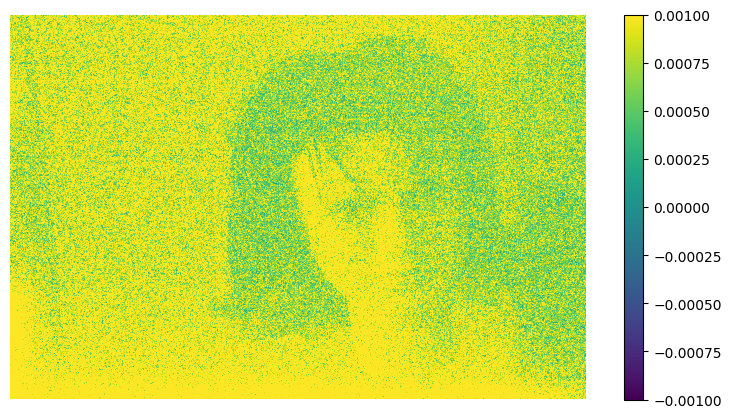

In [6]:
vmax = 0.001; vmin=-vmax
visualize(real_noisy[0,:,:], vmin, vmax)

# read a dark frame

In [7]:
def load_darkframe(path):
    img_info = scipy.io.loadmat(path)
    img = img_info["Inoisy_crop"].astype(np.float32)
    img = (img - 512.) / (16383. - 512.)
    img = pack_np_raw(img)

    return img

In [8]:
data_path = '/scratch/students/2023-fall-sp-liying/dataset/Sony_Bias_Frame/ISO%d/0001_ISO%d.mat' % (iso_value, iso_value)
real_darkframe = load_darkframe(data_path)
real_darkframe = real_darkframe.transpose(2,0,1)

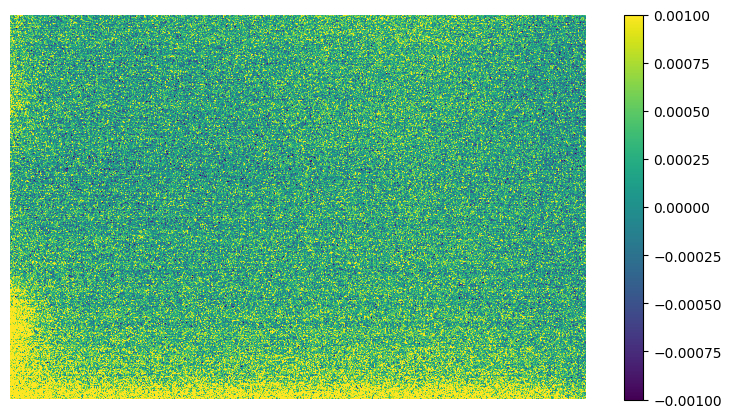

In [9]:
visualize(real_darkframe[0,:,:], vmin, vmax)

In [10]:
def apply_gaussian_blur(reference, sigma=50):
    reference_blurred = scipy.ndimage.gaussian_filter(reference, sigma=sigma)
    return reference_blurred
    

In [11]:
darkshading = apply_gaussian_blur(real_darkframe, sigma=50)

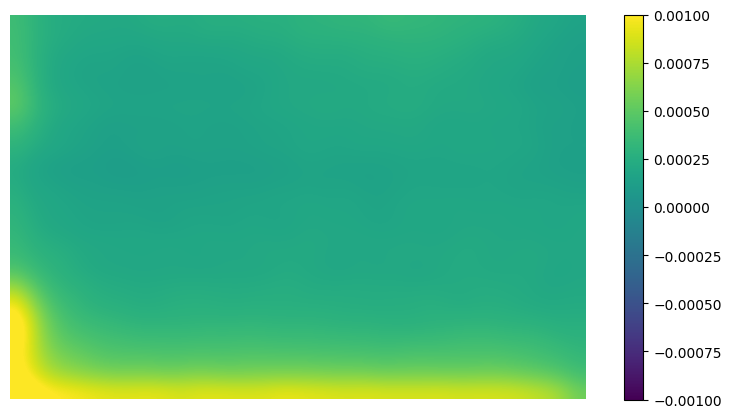

In [12]:
visualize(darkshading[0,:,:], vmin, vmax)

# Estimate $k_{iso}$

In [13]:
def get_mean_var(img, k):
    """
    img, noisy image with shape of (C, H, W) in torch
    """
    C, H, W = img.shape

    img = img.unsqueeze(0)
    patches = F.unfold(img, kernel_size=k)  # shape: (1, C*k*k, L), L=(H-k+1)*(W-k+1)
    patches = patches.view(1, C, k*k, -1)  # shape: (1, C, k*k, L)
    mean_map = patches.mean(dim=2)  # shape: (1, C, L)
    
    mean_values = mean_map.round().view(-1)  # shape: (C*L)
    noisy_values = patches.permute(0, 1, 3, 2)  # shape: (1, C, L, k*k)
    noisy_values = noisy_values.contiguous().view(-1, k*k)  # shape: (C*L, k*k)
    mean_list, var_list, num_list = group_same_means(mean_values.cpu().numpy(), noisy_values.cpu().numpy(), threshold=32)


    return mean_list, var_list, num_list


def group_same_means(mean_values, noisy_values, threshold=32, max_mean=16383):
    """
    mean_values: shape (N,)
    noisy_values: shape (N, k*k)
    """
    mean_values = mean_values.astype(np.int32)
    # Flatten noisy_values and compute variance incrementally
    # Step 1: compute counts per mean
    counts = np.bincount(mean_values, minlength=max_mean+1)

    # Step 2: compute sum and sum of squares per mean (for variance)
    sums = np.bincount(
        mean_values.repeat(noisy_values.shape[1]),
        noisy_values.ravel(),
        minlength=max_mean+1
    )
    sums_sq = np.bincount(
        mean_values.repeat(noisy_values.shape[1]),
        noisy_values.ravel() ** 2,
        minlength=max_mean+1
    )

    # Each mean is counted `count_i * k*k` times
    total_counts = counts * noisy_values.shape[1]

    # Filter by threshold
    mask = total_counts >= threshold
    valid_means = np.nonzero(mask)[0]

    # Compute variance: Var = E[x^2] - (E[x])^2
    mean_vals = sums[valid_means] / total_counts[valid_means]
    var_vals = sums_sq[valid_means] / total_counts[valid_means] - mean_vals**2
    num_vals = total_counts[valid_means]

    return valid_means, var_vals, num_vals



def estimate_kiso(img, patch_size=3):
    """
    img, noisy image with shape of (C, H, W) in torch, value range: [0, 1]
    """
    C, H, W = img.shape

    img_scale = (img * (16383 - 512)).clip(0, 16383 - 512)
    mean_list, var_list, num_list = get_mean_var(img_scale, k=patch_size)
    
    return mean_list, var_list, num_list

# Estimate for all ISO values

In [14]:
# get the unique iso values
train_path = "/scratch/students/2023-fall-sp-liying/dataset/SID/Sony_train_list.txt"
test_path = "/scratch/students/2023-fall-sp-liying/dataset/SID/Sony_test_list.txt"
data_folder = "/scratch/students/2023-fall-sp-liying/dataset/SID"
info_list = []

i = 0

with open(train_path, 'r') as file:
    for line in file:
        if line:
            i += 1
            in_path, gt_path, iso, fvalue = line.split(' ')
            iso = int(iso.replace('ISO', ''))

            in_fn = os.path.basename(in_path)
            gt_fn = os.path.basename(gt_path)
            test_id = int(in_fn[0:5])
            in_exposure = float(in_fn[9:-5])
            gt_exposure = float(gt_fn[9:-5])
            ratio = min(gt_exposure / in_exposure, 300)
            
            info_list.append(iso)
            
info_list = np.unique(info_list, axis=0)
iso_list = [iso for iso in info_list]

In [15]:
print(iso_list)

[50, 64, 80, 100, 160, 200, 250, 320, 400, 500, 640, 800, 1000, 1250, 1600, 2000, 2500, 4000, 5000, 6400, 8000, 10000, 12800, 16000, 25600]


iso: 50, coef: 0.43350, intercept: 0.19012, score: 0.94573


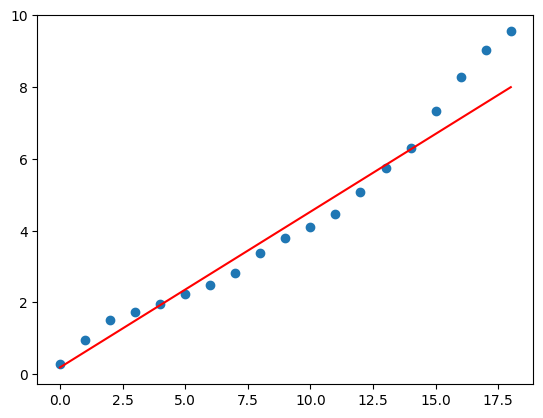

iso: 64, coef: 0.24496, intercept: 0.84156, score: 0.94727


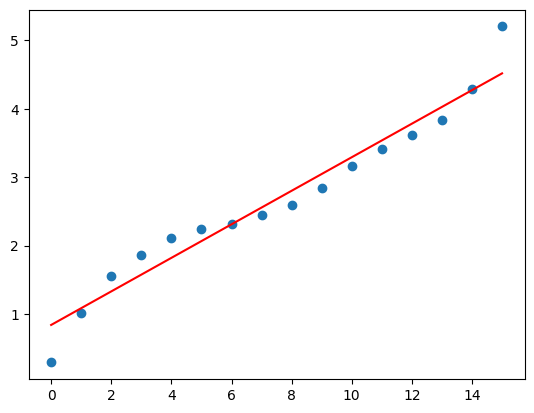

iso: 80, coef: 0.46703, intercept: -0.12380, score: 0.97496


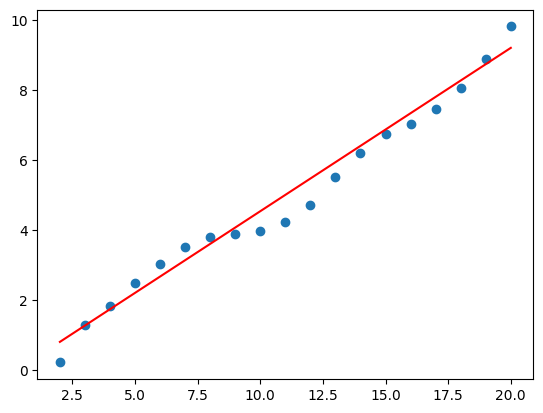

iso: 100, coef: 0.51079, intercept: 0.37664, score: 0.97065


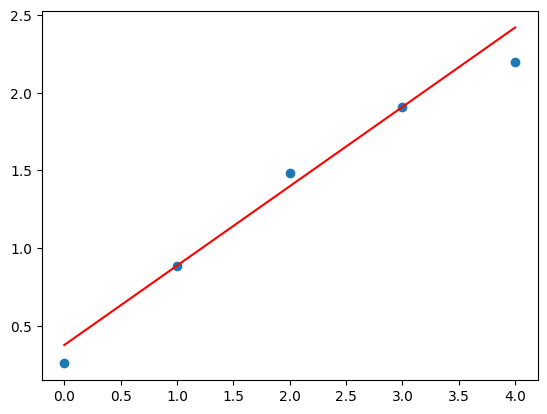

iso: 160, coef: 0.51975, intercept: 1.39938, score: 0.71544


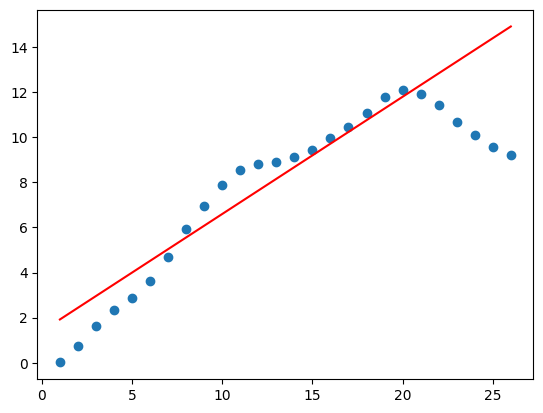

iso: 200, coef: 1.59698, intercept: -5.24355, score: 0.94506


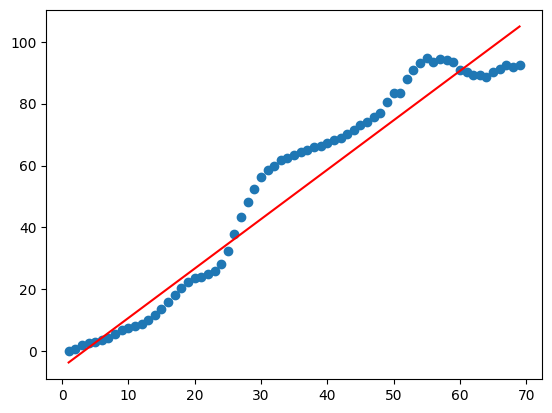

iso: 250, coef: 1.15894, intercept: -0.72893, score: 0.96890


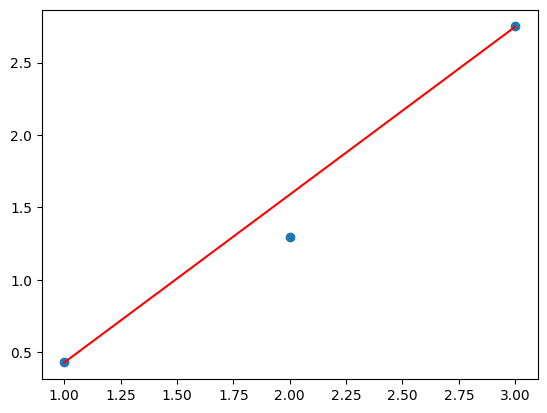

iso: 320, coef: 0.79754, intercept: 0.73563, score: 0.98298


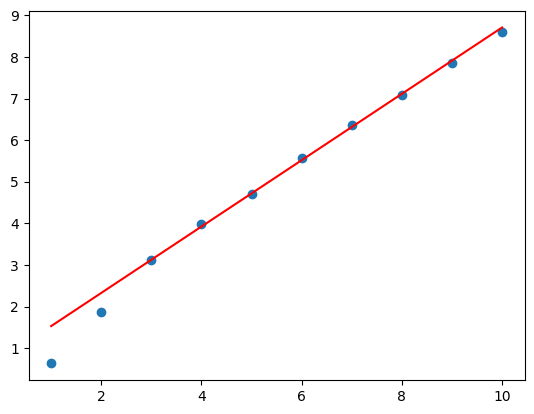

iso: 400, coef: 1.21234, intercept: 0.02437, score: 0.99283


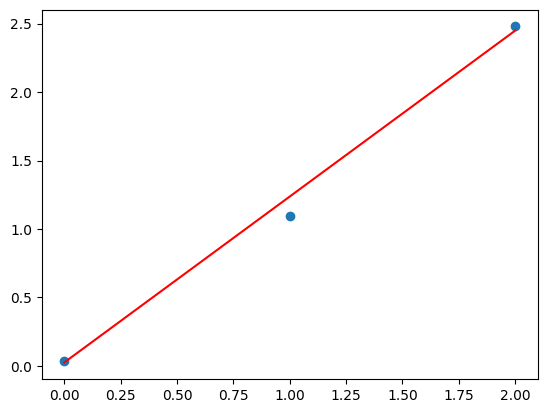

iso: 500, coef: 1.27593, intercept: 0.93507, score: 0.90333


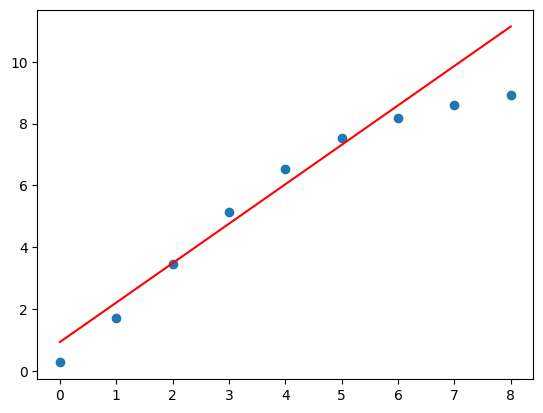

iso: 640, coef: 2.23473, intercept: 0.47975, score: 0.98217


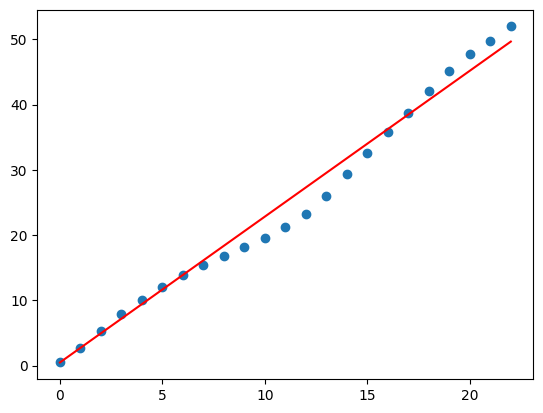

iso: 800, coef: 1.88598, intercept: 2.98979, score: 0.97848


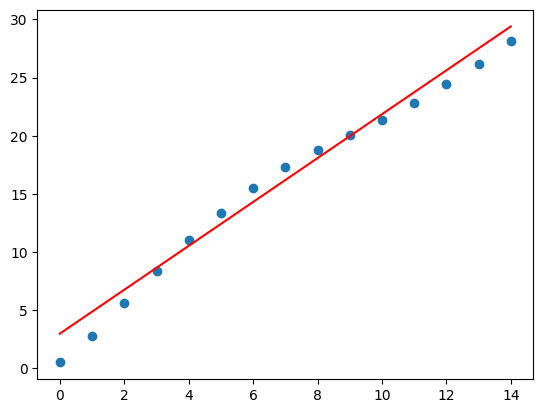

iso: 1000, coef: 1.80168, intercept: 7.68264, score: 0.94357


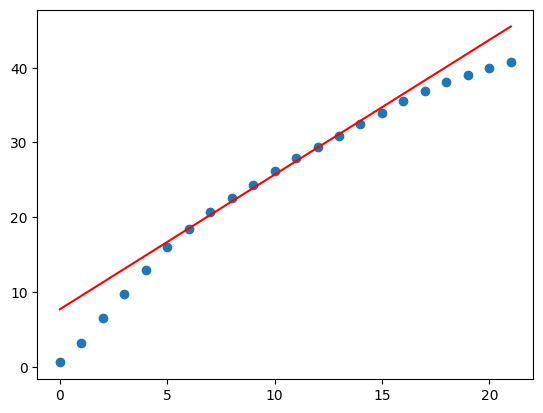

iso: 1250, coef: 4.58671, intercept: 0.15727, score: 0.99954


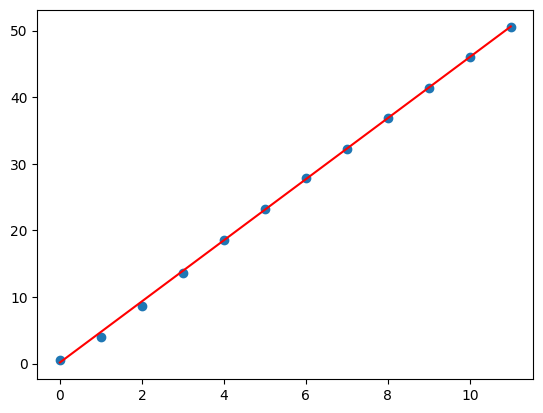

iso: 1600, coef: 5.64322, intercept: -2.54756, score: 0.99179


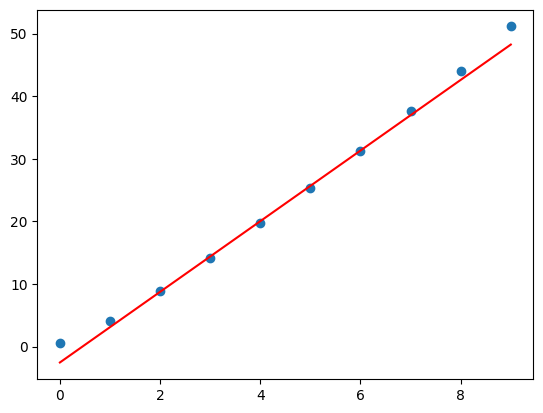

iso: 2000, coef: 2.86536, intercept: -4.89731, score: 0.89745


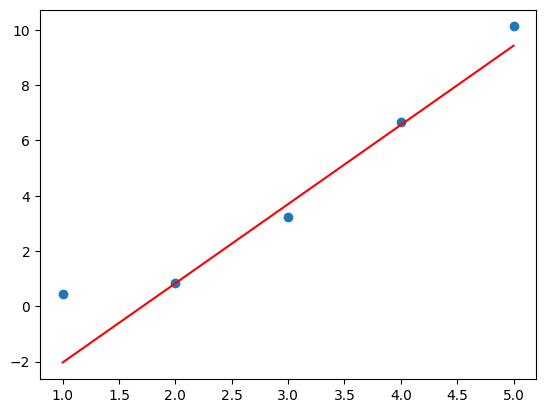

iso: 2500, coef: 2.20770, intercept: -1.93081, score: 0.80168


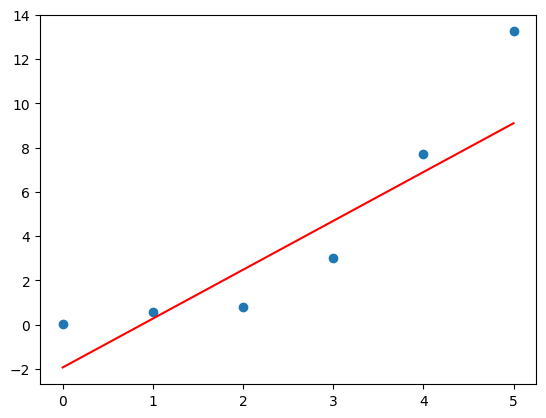

iso: 4000, coef: 5.06548, intercept: -4.94929, score: 0.99157


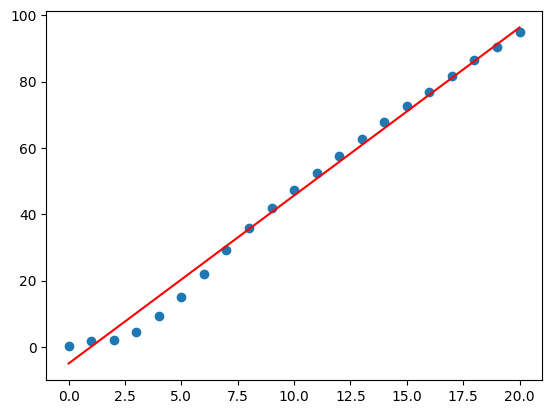

iso: 5000, coef: 7.69055, intercept: -20.12882, score: 0.93430


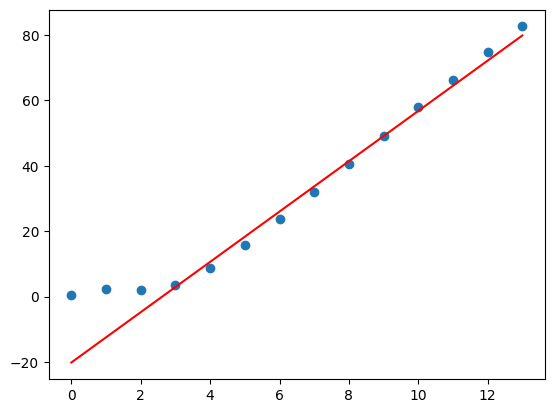

iso: 6400, coef: 7.95938, intercept: -9.04477, score: 0.99225


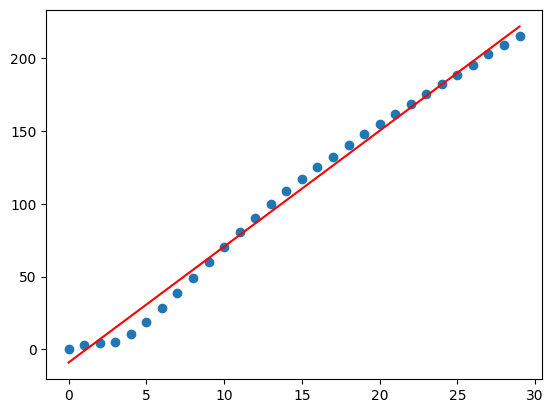

iso: 8000, coef: 10.47473, intercept: -26.83062, score: 0.92346


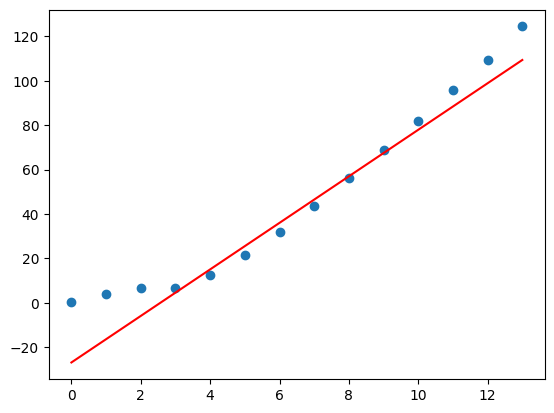

iso: 10000, coef: 14.49813, intercept: -23.63539, score: 0.98747


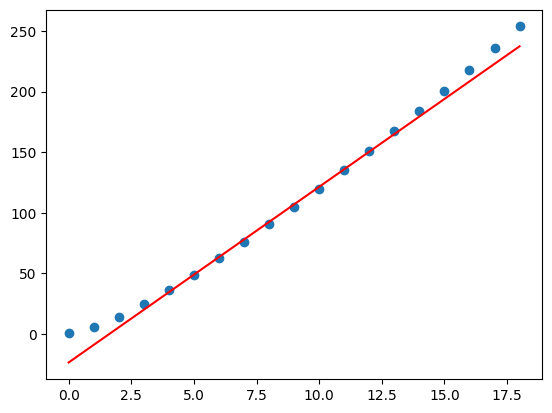

iso: 12800, coef: 15.09306, intercept: -25.94508, score: 0.96943


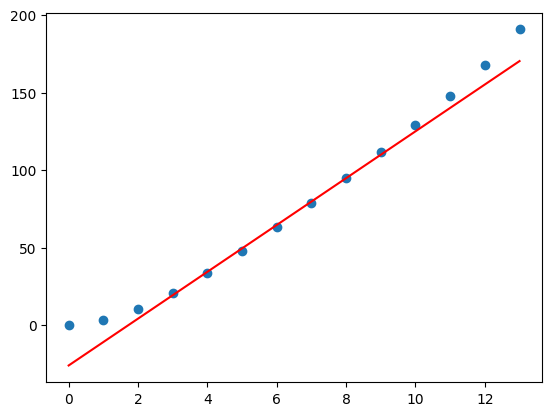

iso: 16000, coef: 19.52321, intercept: -35.14889, score: 0.97265


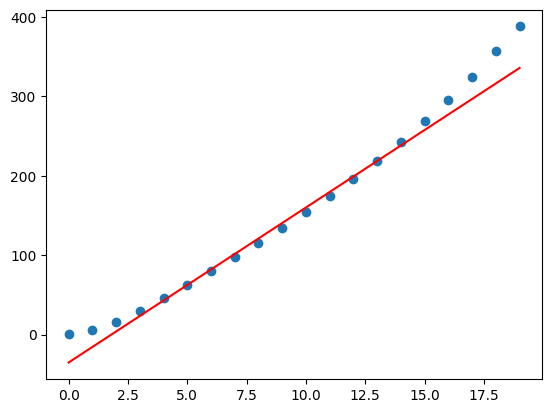

iso: 25600, coef: 29.91506, intercept: -80.23138, score: 0.98194


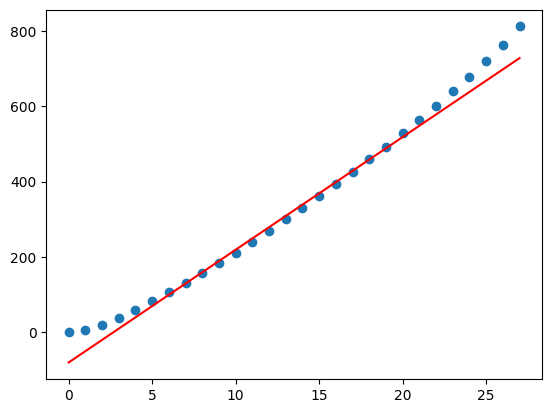

<Figure size 640x480 with 0 Axes>

In [28]:
coef_list = []
intercpt_list = []
for iso_value in iso_list:
    # read noisy image
    pairs = get_files_per_iso(df, iso_value)
    pair = pairs[0]
    noisy_path = os.path.join('/scratch/students/2023-fall-sp-liying/dataset/SID/', pair[0])
    real_noisy = read_raw_to_numpy(noisy_path)
    real_noisy_tensor = torch.from_numpy(real_noisy).float()

    # read dark frame
    data_path = sorted(glob.glob('/scratch/students/2023-fall-sp-liying/dataset/Sony_Bias_Frame/ISO%d/*_ISO%d.mat' % (iso_value, iso_value)))[0]
    real_darkframe = load_darkframe(data_path)
    real_darkframe = real_darkframe.transpose(2,0,1)
    darkshading = apply_gaussian_blur(real_darkframe, sigma=50)
    darkshading_tensor = torch.from_numpy(darkshading).float()
    
    # compute mean var lists
    mean_list, var_list, num_list = estimate_kiso(real_noisy_tensor - darkshading_tensor, patch_size=3)
    
    # linear regression
    mean_list = np.array(mean_list, dtype = np.float32)
    var_list = np.array(var_list)
    
    num_list = np.array(num_list)
    num_cumsum = np.cumsum(num_list)
    num_cumsum = num_cumsum / num_cumsum.max()
    num_valid = len(num_cumsum[num_cumsum<0.95])
            
    model = TheilSenRegressor().fit(mean_list[:num_valid].reshape(-1, 1) , var_list[:num_valid])
    var_star = model.predict(mean_list.reshape(-1, 1))

    coef_list.append(model.coef_)
    intercpt_list.append(model.intercept_)
    
    score = model.score(mean_list[:num_valid].reshape(-1, 1), var_list[:num_valid])
    print('iso: %d, coef: %.5f, intercept: %.5f, score: %.5f' % (iso_value, model.coef_[0], model.intercept_, score))
    plt.scatter(mean_list[:num_valid], var_list[:num_valid])
    plt.plot(mean_list[:num_valid], var_star[:num_valid], c="red")
    plt.show()
    plt.clf()

In [29]:
noise_profile = {}
for i in range(len(iso_list)):
    noise_profile[iso_list[i]] = [coef_list[i][0], intercpt_list[i]]

In [308]:
print(noise_profile)

{50: [0.3894716156726372, -0.11129228016080725], 64: [0.2134849394718346, 0.7850765473396774], 80: [0.47186692830440546, 0.5955914409027194], 100: [0.30380743861827647, 0.6061472007107831], 160: [0.5278547239246755, 2.2139952913901735], 200: [1.5972632925130714, -3.3802257498001573], 250: [1.0962124579954815, 0.31069768999923786], 320: [0.8365122601173914, 1.1474672400287649], 400: [1.3757676421885712, 0.43878252306289134], 500: [1.2197963112577748, 1.421503793643067], 640: [2.240867184733073, 0.5031115527332695], 800: [1.8310414404617392, 2.9694884286413754], 1000: [1.7440379400153232, 7.368108235685562], 1250: [4.15829502852531, 0.791164622799091], 1600: [4.802412336165563, -0.9843857709523566], 2000: [3.3929081429779244, -1.0212499993972186], 2500: [4.514321074305558, -1.9220216944871016], 4000: [5.596065718071887, 1.0780915054154603], 5000: [8.200318987973942, -7.10417399164393], 6400: [8.675180798793082, 0.6278031546344185], 8000: [11.762674876454737, -12.850117000467705], 10000: 

In [ ]:
ssave_folder = './resources'
os.mkdirs(save_folder, exists_ok=True)

with open(os.path.join(save_folder, 'sid_noise_profile_from_single_noisy.pkl'), 'wb') as file:
    pickle.dump(noise_profile, file)